In [1]:
# run in a cell (you may need to install gmsh and meshio if not present)
# !pip install gmsh==4.11.0 meshio scipy matplotlib numpy

import gmsh
import meshio
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt


# nicer plotting defaults
plt.rcParams.update({'figure.figsize': (8,6), 'font.size': 12})


In [2]:
# Initialize gmsh


# read with meshio
msh_filename2= '/Users/straniero/Documents/Dphil/hyperfish/ell_shape_small.msh'
mesh = meshio.read(msh_filename2)

# Extract points and triangular cells
points = mesh.points[:, :2]   # (x,y) but represents (z,r)
cells = None
for cell_block in mesh.cells:
    if cell_block.type == "triangle":
        cells = cell_block.data
        break


if cells is None:
    raise RuntimeError("No triangular cells found in mesh.")

print("Nodes:", points.shape[0], "Triangles:", cells.shape[0])


radius = np.max(points[:,1])  # max r value from points
L = np.max(points[:,0])       # max z value from points


Nodes: 3810 Triangles: 7367


In [ ]:
etc=mesh.field_data


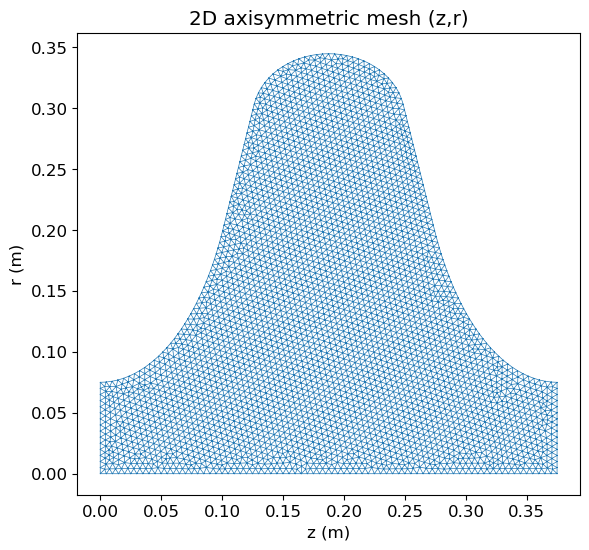

In [3]:
# quick mesh plot
plt.triplot(points[:,0], points[:,1], cells, lw=0.5)
plt.gca().set_aspect('equal')
plt.xlabel('z (m)')
plt.ylabel('r (m)')
plt.title('2D axisymmetric mesh (z,r)')
plt.show()


In [286]:
# Helper: assemble element stiffness and mass for a triangle
def triangle_matrices(coords):
    # coords: 3x2 array of node coordinates [[z1,r1],[z2,r2],[z3,r3]]
    x1,y1 = coords[0]; x2,y2 = coords[1]; x3,y3 = coords[2]
    # area
    det = (x2-x1)*(y3-y1) - (x3-x1)*(y2-y1)
    area = 0.5 * abs(det)
    if area <= 0:
        return None, None

    # Gradients of barycentric shape functions:
    # phi_i has gradient grad phi_i = [dphi/dx, dphi/dy]
    # Using formula from linear triangle
    B = np.zeros((3,2))
    # compute coefficients for shape function gradients (standard)
    # grad phi1 = [(y2 - y3), (x3 - x2)] / det*? careful with sign
    # We'll compute using solving linear system: phi = a + b x + c y; phi=1 at node i
    A_mat = np.array([[1, x1, y1],
                      [1, x2, y2],
                      [1, x3, y3]])
    grads = np.zeros((3,2))
    for i in range(3):
        rhs = np.zeros(3); rhs[i] = 1.0
        # solve for coefficients [a, b, c] with A_mat @ [a,b,c] = rhs
        a_b_c = np.linalg.solve(A_mat, rhs)
        grads[i,:] = a_b_c[1:]   # b,c are derivatives w.r.t x,y

    # local stiffness ke_ij = ∫ (grad phi_i . grad phi_j) * r * dA
    # local mass me_ij = ∫ phi_i * phi_j * r * dA
    # approximate r by centroid r_c
    r_c = (y1 + y2 + y3) / 3.0

    ke = np.zeros((3,3))
    me = np.zeros((3,3))

    for i in range(3):
        for j in range(3):
            ke[i,j] = (grads[i].dot(grads[j])) * (r_c * area)
            # mass for linear triangle: ∫ phi_i phi_j dA -> area * (1/12) if i!=j, area*(1/6) if i==j
            me[i,j] = (area * r_c) * (1.0/12.0 if i != j else 1.0/6.0)

    return ke, me

# Build sparse matrices
n_nodes = points.shape[0]
row = []
col = []
data_A = []
data_M = []

for tri in cells:
    coords = points[tri]   # 3x2
    ke, me = triangle_matrices(coords)
    if ke is None:
        continue
    for a in range(3):
        for b in range(3):
            row.append(tri[a])
            col.append(tri[b])
            data_A.append(ke[a,b])
            data_M.append(me[a,b])

A = sp.coo_matrix((data_A, (row, col)), shape=(n_nodes, n_nodes)).tocsr()
M = sp.coo_matrix((data_M, (row, col)), shape=(n_nodes, n_nodes)).tocsr()

print("Assembled matrices: A shape", A.shape, "nnz", A.nnz, " ; M nnz", M.nnz)


Assembled matrices: A shape (1077, 1077) nnz 7265  ; M nnz 7265


In [287]:
# find boundary nodes approximately
tol = mesh_size * 0.5
z = points[:,0]; r = points[:,1]
on_r_outer = np.isclose(r, radius, atol=tol)
on_z0 = np.isclose(z, 0.0, atol=tol)
on_zL = np.isclose(z, length, atol=tol)

# We'll treat walls (outer r and z ends) as Dirichlet (H=0)
dirichlet_nodes = np.where(on_r_outer | on_z0 | on_zL)[0]

print("Dirichlet nodes (count):", dirichlet_nodes.size)

# Build masks
free_dofs = np.ones(n_nodes, dtype=bool)
free_dofs[dirichlet_nodes] = False

# Modify matrices: zero rows & cols for dirichlet nodes, set diag = 1 in M and A
A_mod = A.tolil()
M_mod = M.tolil()

for ii in dirichlet_nodes:
    A_mod.rows[ii] = [ii]
    A_mod.data[ii] = [1.0]
    M_mod.rows[ii] = [ii]
    M_mod.data[ii] = [1.0]

# Also zero columns (symmetry)
A_mod = A_mod.tocsr()
M_mod = M_mod.tocsr()

for ii in dirichlet_nodes:
    A_mod[:,ii] = sp.csr_matrix((n_nodes,1))
    A_mod[ii,ii] = 1.0
    M_mod[:,ii] = sp.csr_matrix((n_nodes,1))
    M_mod[ii,ii] = 1.0

A_mod = A_mod.tocsr()
M_mod = M_mod.tocsr()


Dirichlet nodes (count): 118


In [289]:
k_eigs = 100 # number of eigenvalues to compute
which = 'SM'  # smallest magnitude

# convert to symmetric sparse
A_sym = (A_mod + A_mod.T) * 0.5
M_sym = (M_mod + M_mod.T) * 0.5

# Use eigsh
# Note: generalized eigenproblem sometimes requires shift-invert; try eigsh directly first
try:
    vals, vecs = spla.eigsh(A_sym, k=k_eigs, M=M_sym, sigma=0.0, which='LM', tol=1e-3)
    # using shift-invert around 0 usually finds smallest positive eigenvalues
except Exception as e:
    print("eigsh shift-invert failed:", e)
    # fallback: try sparse.linalg.eigsh without M (not ideal)
    vals, vecs = spla.eigsh(A_sym, k=k_eigs, which='SM', tol=1e-3)

# eigenvalues returned are lambda = k^2 (depending on scale). Sort them
idx = np.argsort(np.real(vals))
vals = np.real(vals[idx])
vecs = vecs[:, idx]

#print("Computed eigenvalues (k^2):", vals)
# convert to frequency: k = sqrt(vals); f = c*k/(2*pi)
c = 299792458.0
ks = np.sqrt(np.maximum(vals, 0.0))
freqs = ks * c / (2*np.pi)
print("Approx frequencies (Hz):", freqs)


Approx frequencies (Hz): [4.77134516e+07 4.77134516e+07 4.77134516e+07 4.77134516e+07
 4.77134516e+07 4.77134516e+07 4.77134516e+07 4.77134516e+07
 4.77134516e+07 4.77134516e+07 4.77134516e+07 4.77134516e+07
 4.77134516e+07 4.77134516e+07 4.77134516e+07 4.77134516e+07
 4.77134516e+07 4.77134516e+07 4.77134516e+07 4.77134516e+07
 4.77134516e+07 4.77134516e+07 4.77134516e+07 4.77134516e+07
 4.77134516e+07 4.77134516e+07 4.77134516e+07 4.77134516e+07
 4.77134516e+07 4.77134516e+07 4.77134516e+07 4.77134516e+07
 4.77134516e+07 4.77134516e+07 4.77134516e+07 4.77134516e+07
 4.77134516e+07 4.77134516e+07 4.77134516e+07 4.77134516e+07
 4.77134516e+07 4.77134516e+07 4.77134516e+07 4.77134516e+07
 4.77134516e+07 4.77134516e+07 4.77134516e+07 4.77134516e+07
 4.77134516e+07 4.77134516e+07 4.77134516e+07 4.77134516e+07
 4.77134516e+07 4.77134516e+07 4.77134516e+07 4.77134516e+07
 4.77134516e+07 4.77134516e+07 4.77134516e+07 4.77134516e+07
 4.77134516e+07 4.77134516e+07 4.77134516e+07 4.77134516e+07

In [290]:
vecs_refined = []
ks_refined = []
freqs_refined = []
for i in range(len(ks)):
    if ks[i] >= 1.0001:
        vecs_refined.append(vecs[:,i])  # this is the eigenvector for mode i
        ks_refined.append(ks[i])  # this is the k for mode i
        freqs_refined.append(freqs[i])  # this is the frequency for mode i

In [291]:
np.shape(vecs_refined)

(36, 1077)

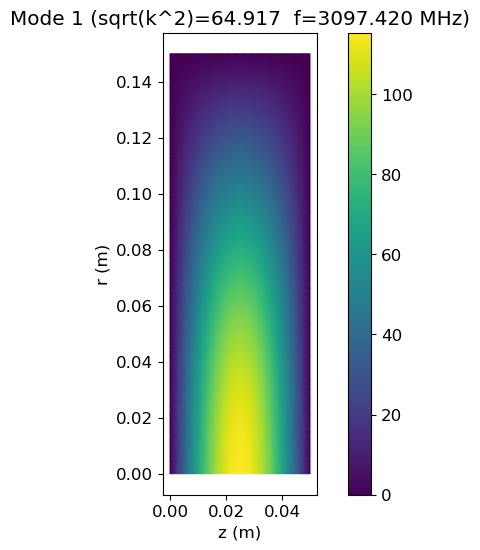

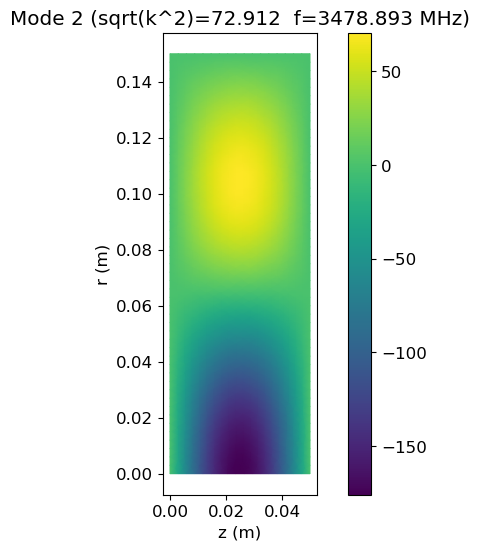

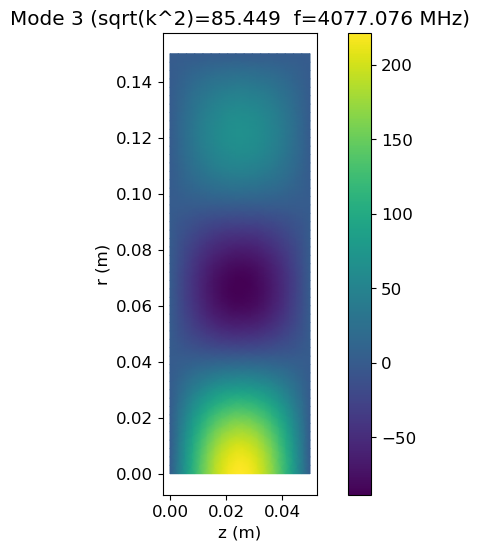

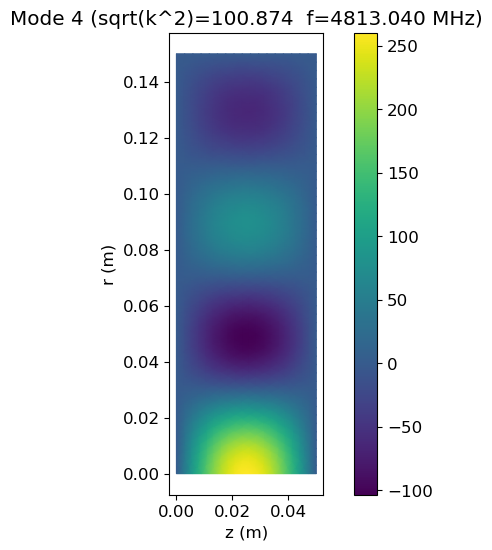

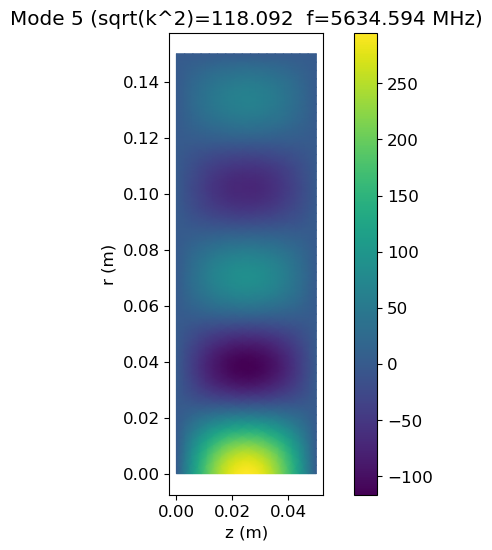

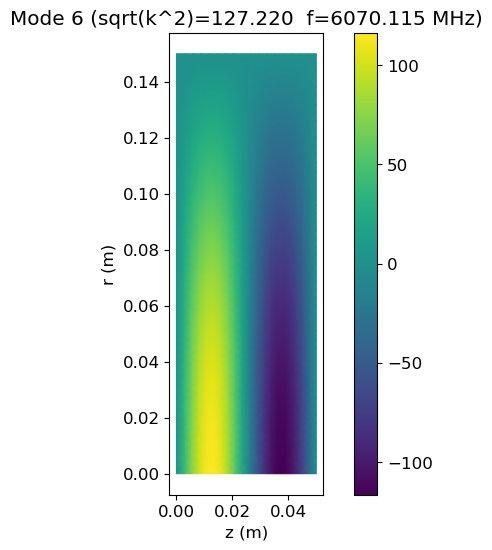

In [292]:
from matplotlib.tri import Triangulation, TriAnalyzer, UniformTriRefiner

triang = Triangulation(points[:,0], points[:,1], cells)
n_plot = min(6, vecs.shape[1])

for i in range(n_plot):
    mode = vecs_refined[i]
    # mask nodes that were Dirichlet to zero (should already be)
    mode_vis = mode.real
    plt.figure()
    tpc = plt.tripcolor(triang, mode_vis, shading='gouraud')
    plt.colorbar(tpc)
    plt.gca().set_aspect('equal')
    plt.title(f"Mode {i+1} (sqrt(k^2)={ks_refined[i]:.3f}  f={freqs_refined[i]/1e6:.3f} MHz)")
    plt.xlabel("z (m)")
    plt.ylabel("r (m)")
    plt.show()


In [293]:

# Physical constant
eps0 = 8.8541878128e-12  # vacuum permittivity, F/m

# choose mode index to use (0-based). Pick first nontrivial mode (0) by default.
mode_index = 0

# H values at nodes for the chosen eigenmode (complex)
H_nodes = vecs_refined[mode_index].astype(np.complex128)

# Precompute element areas and shape-function gradients
n_tri = cells.shape[0]
tri_areas = np.zeros(n_tri)
# grads_elem[i] will be (dH/dz, dH/dr) constant over triangle i
grads_elem = np.zeros((n_tri, 2), dtype=np.complex128)

for t_idx, tri in enumerate(cells):
    coords = points[tri]  # shape (3,2): columns are (z, r)
    x1,y1 = coords[0]; x2,y2 = coords[1]; x3,y3 = coords[2]
    # area (signed)
    det = (x2 - x1)*(y3 - y1) - (x3 - x1)*(y2 - y1)
    area = 0.5 * det
    tri_areas[t_idx] = abs(area)

    # Build A_mat for computing shape function coefficients (same as earlier)
    A_mat = np.array([[1.0, x1, y1],
                      [1.0, x2, y2],
                      [1.0, x3, y3]])
    # compute gradients of the linear shape functions (constant per triangle)
    grads_phi = np.zeros((3,2))
    for i in range(3):
        rhs = np.zeros(3); rhs[i] = 1.0
        a_b_c = np.linalg.solve(A_mat, rhs)
        grads_phi[i,:] = a_b_c[1:]  # [d/dx, d/dy] where x->z and y->r

    # now compute grad H = sum_i H_i * grad phi_i
    H_local = H_nodes[tri]
    gradH = H_local @ grads_phi   # shape (2,) complex
    # gradH[0] = dH/dz, gradH[1] = dH/dr
    grads_elem[t_idx,:] = gradH

# Now average element gradients to nodes (area-weighted)
n_nodes = points.shape[0]
gradH_nodes = np.zeros((n_nodes, 2), dtype=np.complex128)
area_accum = np.zeros(n_nodes, dtype=np.float64)

for t_idx, tri in enumerate(cells):
    a = tri_areas[t_idx]
    for ni in tri:
        gradH_nodes[ni] += grads_elem[t_idx] * a
        area_accum[ni] += a

# avoid division by zero for isolated nodes
nonzero = area_accum > 0
gradH_nodes[nonzero] /= area_accum[nonzero][:,None]
gradH_nodes[~nonzero] = 0.0

dH_dz = gradH_nodes[:,0]   # ∂H/∂z
dH_dr = gradH_nodes[:,1]   # ∂H/∂r

print("Computed nodal gradients. Example dH/dz (first 5):", dH_dz[:5])
print("Computed nodal gradients. Example dH/dr (first 5):", dH_dr[:5])


Computed nodal gradients. Example dH/dz (first 5): [ 7216.27202238+0.j -7218.64913016+0.j   -64.41437193+0.j
    66.73585895+0.j  7089.78259041+0.j]
Computed nodal gradients. Example dH/dr (first 5): [  0.5672555 +0.j   2.10050459+0.j -63.15134503+0.j -65.4273127 +0.j
  -1.21768789+0.j]


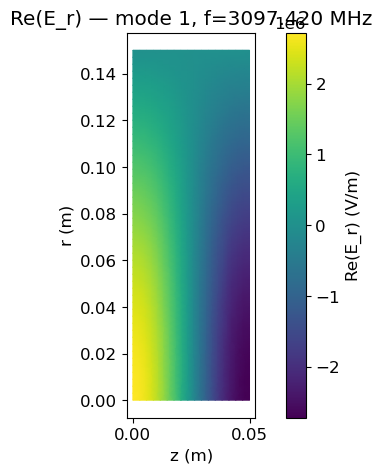

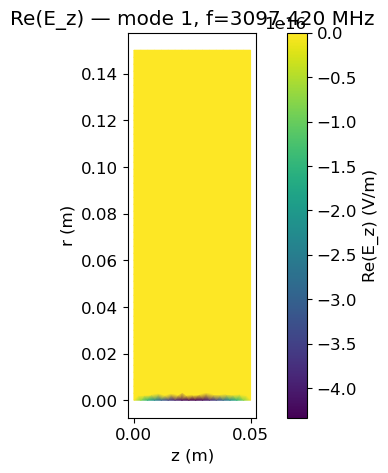

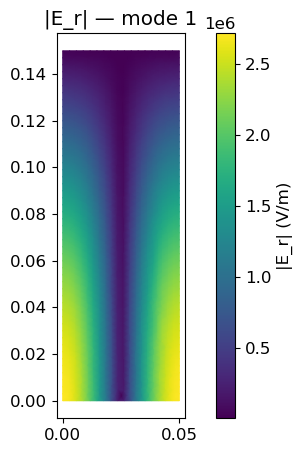

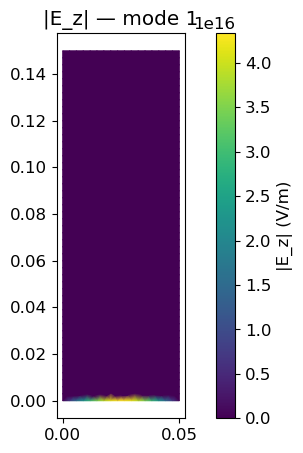

In [294]:
import matplotlib.pyplot as plt
from matplotlib.tri import Triangulation

# angular frequency for chosen mode
omega = 2*np.pi * freqs[mode_index]  # freqs was computed earlier (Hz)

# compute E fields using the formulas:
# E_r = -1/(j ω ε0) * ∂H/∂z
# E_z =  1/(j ω ε0) * ( ∂H/∂r + H/r )

# avoid division by very small r values
z_nodes = points[:,0]; r_nodes = points[:,1]
r_safe = np.maximum(r_nodes, 1e-12)

j = 1j
prefactor = 1.0 / (j * omega * eps0)

E_r_nodes = -prefactor * dH_dz
E_z_nodes =  prefactor * (dH_dr + H_nodes / r_safe)

# For visualization, take real part or magnitude.
E_r_real = E_r_nodes.imag
E_z_real = E_z_nodes.imag
E_r_abs = np.abs(E_r_nodes)
E_z_abs = np.abs(E_z_nodes)

# prepare triangulation
triang = Triangulation(points[:,0], points[:,1], cells)

# Plot real(E_r)
plt.figure(figsize=(8,5))
tpc = plt.tripcolor(triang, E_r_real, shading='gouraud')
plt.colorbar(tpc, label='Re(E_r) (V/m)')
plt.title(f"Re(E_r) — mode {mode_index+1}, f={freqs_refined[mode_index]/1e6:.3f} MHz")
plt.xlabel('z (m)')
plt.ylabel('r (m)')
plt.gca().set_aspect('equal')
plt.show()

# Plot real(E_z)
plt.figure(figsize=(8,5))
tpc = plt.tripcolor(triang, E_z_real, shading='gouraud')
plt.colorbar(tpc, label='Re(E_z) (V/m)')
plt.title(f"Re(E_z) — mode {mode_index+1}, f={freqs_refined[mode_index]/1e6:.3f} MHz")
plt.xlabel('z (m)')
plt.ylabel('r (m)')
plt.gca().set_aspect('equal')
plt.show()

# Plot magnitudes
plt.figure(figsize=(8,5))
tpc = plt.tripcolor(triang, E_r_abs, shading='gouraud')
plt.colorbar(tpc, label='|E_r| (V/m)')
plt.title(f"|E_r| — mode {mode_index+1}")
plt.gca().set_aspect('equal')
plt.show()

plt.figure(figsize=(8,5))
tpc = plt.tripcolor(triang, E_z_abs, shading='gouraud')
plt.colorbar(tpc, label='|E_z| (V/m)')
plt.title(f"|E_z| — mode {mode_index+1}")
plt.gca().set_aspect('equal')
plt.show()


In [295]:

from matplotlib.tri import Triangulation, LinearTriInterpolator

# Use real part for instantaneous field
Ez_plot = E_z_nodes.imag
Er_plot = E_r_nodes.imag

triang = Triangulation(points[:,0], points[:,1], cells)

interp_Ez = LinearTriInterpolator(triang, Ez_plot)
interp_Er = LinearTriInterpolator(triang, Er_plot)

# Regular grid
nz = 300
nr = 300

z_min, z_max = points[:,0].min(), points[:,0].max()
r_min, r_max = points[:,1].min(), points[:,1].max()

z_grid = np.linspace(z_min, z_max, nz)
r_grid = np.linspace(r_min, r_max, nr)

Z, R = np.meshgrid(z_grid, r_grid)

Ez_grid = interp_Ez(Z, R)
Er_grid = interp_Er(Z, R)

# Mask outside mesh
mask = np.isnan(Ez_grid)
Ez_grid = np.ma.array(Ez_grid, mask=mask)
Er_grid = np.ma.array(Er_grid, mask=mask)


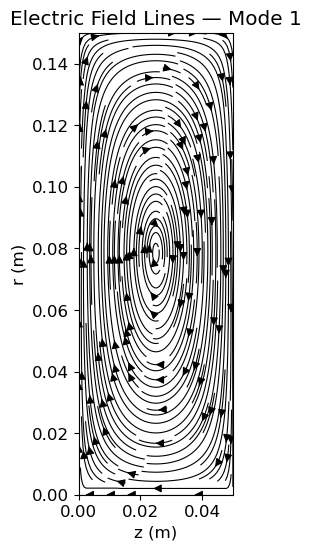

In [296]:
plt.figure(figsize=(8,6))

plt.streamplot(
    z_grid,
    r_grid,
    Ez_grid,
    Er_grid,
    density=2.0,        # increase for more lines
    linewidth=0.8,
    arrowsize=1.2,
    color='black'
)

plt.title(f"Electric Field Lines — Mode {mode_index+1}")
plt.xlabel("z (m)")
plt.ylabel("r (m)")
plt.gca().set_aspect('equal')

plt.xlim(z_min, z_max)
plt.ylim(r_min, r_max)

plt.show()
